## Diffusion model: ECG Dataset

Author: diego.camarero@estudiante.uam.es

In [ ]:
!pip install -q wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 59.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
experiment_number = '09'

kernel_sizes = (9, 9, 9, 9)

lambda_min = 0.05
lambda_max = 5.0

dataset_size = 9246
n_points = 500

epoch_to_load = 500

experiment_name = f"training_diffusion_{experiment_number}_ECG"

In [ ]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/notebooks'
%cd "{PROJECT_PATH}"


BASE_DIR = os.path.abspath("..")
CHECKPOINTS_DIR = os.path.join(BASE_DIR, "checkpoints")

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/notebooks

[INFO] Running on device: cuda



In [ ]:
from utils.reproducibility import seed_everything, seed_worker

seed = 42
seed_everything(seed)

In [ ]:
# Jupyter
# %load_ext autoreload
# %autoreload 2

# Standard library
from functools import partial

# Third-party
import numpy as np

# PyTorch
import torch
from torch.optim import Adam

# Project modules
import diffusion.diffusion_process as dfp

from models.score_model import UNetScoreModel

from data.ecg_dataset import (
    load_ecg_data,
)

from utils.metrics import (
    compute_dataset_metrics,
    full_report,
    checkpoint_summary,
)


from utils.checkpoints import (
    load_checkpoint,
)

from utils.training_plots import (
    plot_function_grid,
    plot_ou_diffusion_process,
    plot_distribution_convergence,
)

In [ ]:
from pathlib import Path
from datetime import datetime

RESULTS_DATA_DIR = Path("../../results/data")
RESULTS_DATA_DIR.mkdir(parents=True, exist_ok=True)

def save_tensor_bundle(filename, **kwargs):
    payload = {"timestamp": datetime.now().isoformat()}
    for k, v in kwargs.items():
        payload[k] = v.detach().cpu() if torch.is_tensor(v) else v

    path = RESULTS_DATA_DIR / filename
    torch.save(payload, path)
    size_mb = path.stat().st_size / 1e6
    print(f"Saved -> {path}  ({size_mb:.2f} MB)")
    return path

## Dataset creation

In [ ]:
from data.ecg_dataset import apply_bandpass_filter

LEAD = 1
SAMPLING_RATE = 100 # or 500
MAX_SAMPLES = 9246
DATASET_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/ECG dataset/'

CACHE_PATH = DATASET_PATH + f'cache_lead{LEAD}_sr{SAMPLING_RATE}_n{MAX_SAMPLES}.pt'

print("Loading from cache...")
checkpoint = torch.load(CACHE_PATH)
data_train = checkpoint['data'][:dataset_size, :, :n_points]
data_train = apply_bandpass_filter(data_train, SAMPLING_RATE)
print(f"Dataset shape: {data_train.shape}")

# For later metrics comparison
real_metrics_df = compute_dataset_metrics(data_train, fs=SAMPLING_RATE)
real_ok_df = real_metrics_df[real_metrics_df['success']]

# Normalize dataset
data_mean = data_train.mean()
data_std = data_train.std()
data_eps = 1e-8
data_train_norm = (data_train - data_mean) / (data_std + data_eps)

Loading from cache...
Dataset shape: torch.Size([9246, 1, 500])


torch.Size([8, 1, 500])


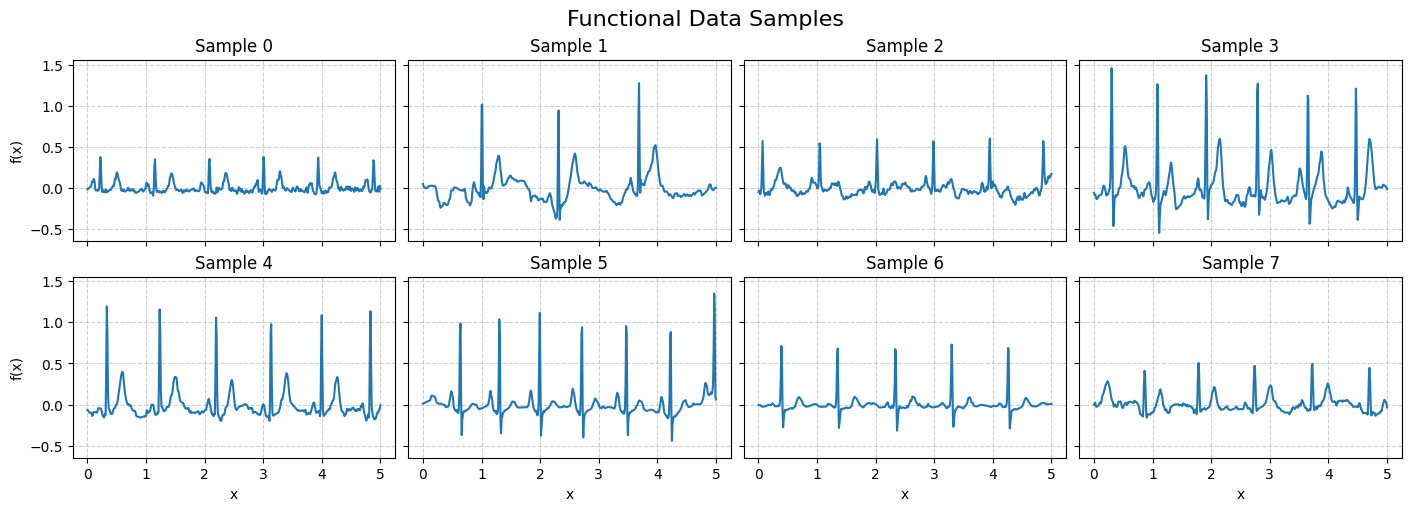

In [ ]:
# Create functional dataset

N, _, M = data_train.shape
x_inf, x_sup = 0.0, 5.0
axis_x = torch.linspace(x_inf, x_sup, M)

# Plot some examples of the dataset

n_examples = 8
examples = torch.stack([data_train[i] for i in range(n_examples)])
print(examples.shape)

plot_function_grid(
    examples,
    n_plots=n_examples,
    axis_x=axis_x,
)

In [ ]:
# save training dataset
save_tensor_bundle(
    "dataset_samples.pt",
    data=data_train,
    data_eps=data_eps,
    seed=seed,
    x_inf=x_inf,
    x_sup=x_sup,
    sampling_rate=SAMPLING_RATE,
)

Saved -> ../../results/data/dataset_samples.pt  (18.49 MB)


PosixPath('../../results/data/dataset_samples.pt')

## Diffusion process

In [ ]:
t_0 = 0.0
T = 1.0
t_eps = 1.0e-3

lambda_t = lambda t: lambda_min + (t-t_0) / (T-t_0) * (lambda_max - lambda_min)

def drift_coefficient(x_t, t):
    t = t.view(-1, 1, 1)
    return - lambda_t(t) * x_t

def diffusion_coefficient(t):
    t = t.view(-1, 1, 1)
    return torch.sqrt(2 * lambda_t(t))

def mu_t(x_0, t):
    return x_0 * torch.exp(-lambda_min*(t-t_0) - (t-t_0)**2 / (2*(T-t_0)) * (lambda_max - lambda_min))

def sigma_t(t):
    return torch.sqrt(1 - torch.exp(-2 * lambda_min * (t-t_0) - (t-t_0)**2 /(T-t_0) * (lambda_max - lambda_min)))

def inverse_mu_t(t):
    return torch.exp(lambda_min*(t-t_0) + (t-t_0)**2 / (2*(T-t_0)) * (lambda_max - lambda_min))

diffusion_process = dfp.GaussianDiffusionProcess(
    drift_coefficient,
    diffusion_coefficient,
    mu_t,
    sigma_t,
    t_0=t_0,
    t_end=T,
    t_eps=t_eps,
)

torch.Size([9246, 100, 1, 500])


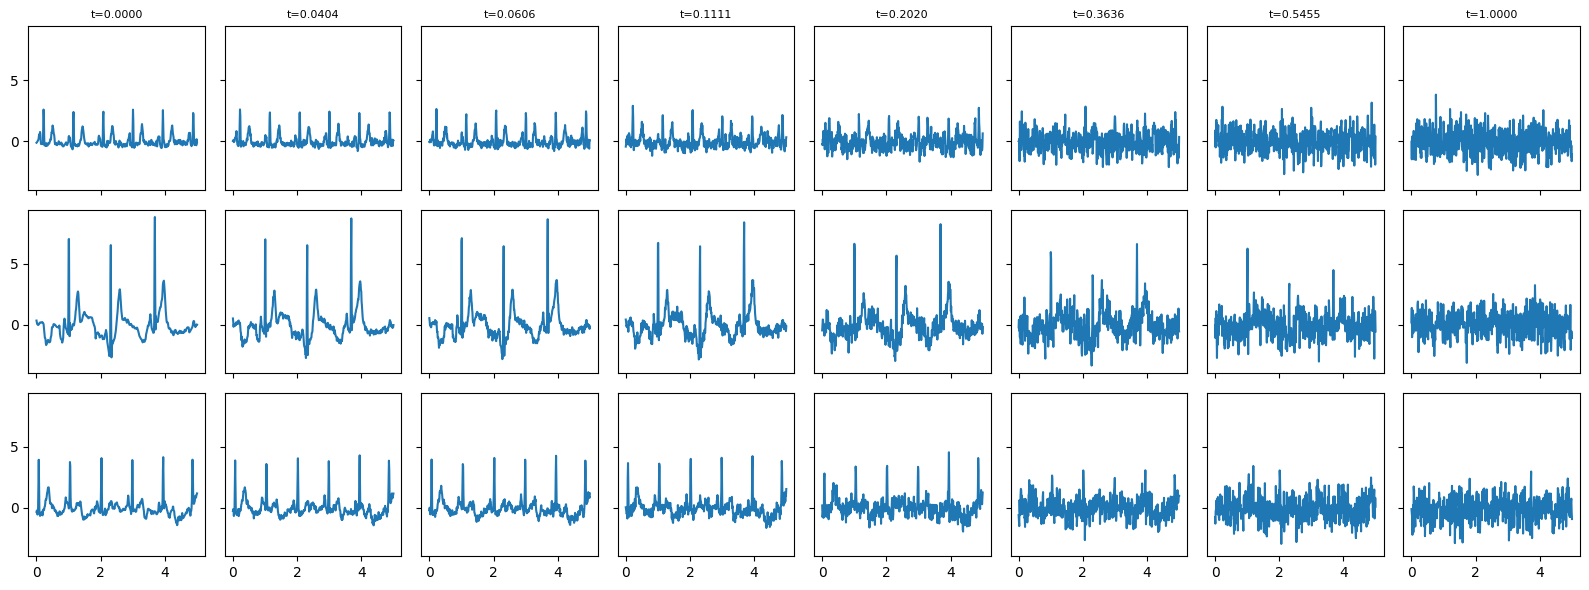

In [ ]:
torch.manual_seed(seed)
n_steps = 100
times, X = dfp.euler_maruyama_integrator(
    x_initial=data_train_norm[:].to(device),
    t_start=t_0,
    t_end=T,
    n_times=n_steps,
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
)
print(X.shape)

plot_ou_diffusion_process(
    X,
    axis_x,
    num_steps=8,
    t_start=t_0,
    t_end=T,
)

In [ ]:
# Save forward diffusion process
save_tensor_bundle(
    "forward_diffusion_process.pt",
    data=X,
    t_0=t_0,
    t_end=T,
    t_eps=t_eps,
)

Saved -> ../../results/data/forward_diffusion_process.pt  (1849.20 MB)


PosixPath('../../results/data/forward_diffusion_process.pt')

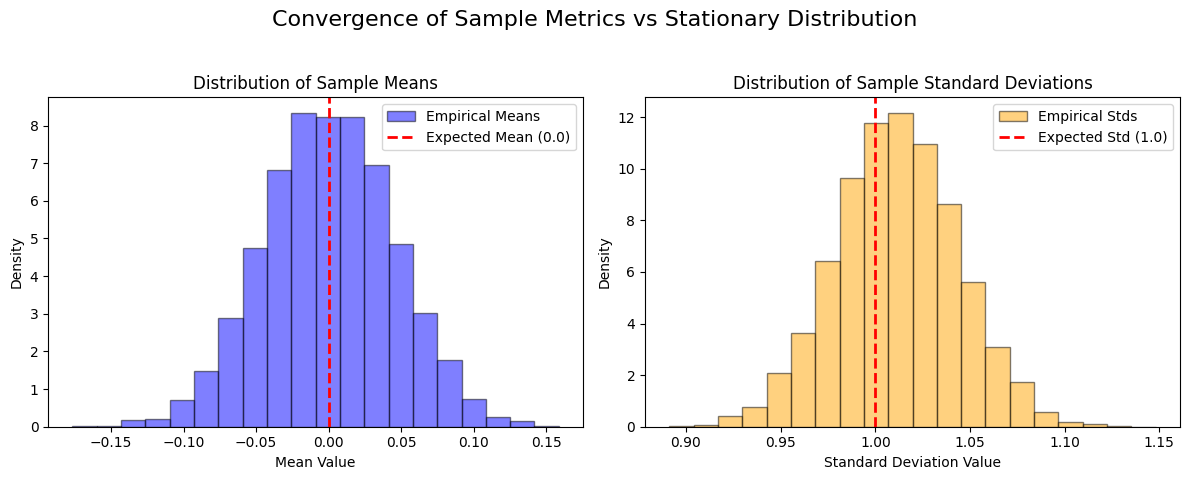

In [ ]:
plot_distribution_convergence(
    X,
    loc_stationary=0.0,
    scale_stationary=1.0,
)

## Synthetic data generation

In [ ]:
# Define the score model

def multiply_inv_sigma(h,t):
    h = h / sigma_t(t)[:, None]
    return h

score_model = UNetScoreModel(
    multiply_inv_sigma=multiply_inv_sigma,
    kernel_sizes=kernel_sizes,
    random_state=seed,
    device=device,
)

learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

In [ ]:
# Compute results

checkpoint_path = os.path.join(
    CHECKPOINTS_DIR,
    experiment_name,
    f"checkpoint_epoch_{epoch_to_load}.pth"
)

def backward_drift_coefficient(x_t, t, drift_coefficient, diffusion_coefficient, score_model):
    score = score_model(x_t, t)
    return drift_coefficient(x_t, t) - diffusion_coefficient(t).view(-1, 1, 1) ** 2 * score

n_functions = 9246
torch.manual_seed(seed)
noise_T = torch.randn(n_functions, 1, M, device=device)

score_model, optimizer, epoch, loss, elapsed_time = load_checkpoint(checkpoint_path, score_model, optimizer)
score_model.eval()

torch.manual_seed(seed)

with torch.no_grad():
  times, synthetic_functions_t = dfp.euler_maruyama_integrator(
      x_initial=noise_T,
      t_start=T,
      t_end=t_0 + t_eps,
      n_times=n_steps,
      drift_coefficient=partial(
          backward_drift_coefficient,
          drift_coefficient=drift_coefficient,
          diffusion_coefficient=diffusion_coefficient,
          score_model=score_model,
          ),
      diffusion_coefficient=diffusion_coefficient,
      )

  synthetic_functions_norm = dfp.inverse_Tweedie_formula(
      x_t=synthetic_functions_t[:, -1, :, :],
      t=t_eps,
      inv_mu_t=inverse_mu_t,
      sigma_t=sigma_t,
      score_model=score_model,
      )

  synthetic_functions = (synthetic_functions_norm * (data_std + data_eps) + data_mean)

Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_09_ECG/checkpoint_epoch_500.pth
Epoch: 500. Loss: 38.443237. Time: 34:46


## Results

In [ ]:
print("Epoch:", epoch)
print("Loss:", loss)

Epoch: 500
Loss: 38.4432374367125


R-peak detection success rate — real: 93.1%, generated: 90.5%


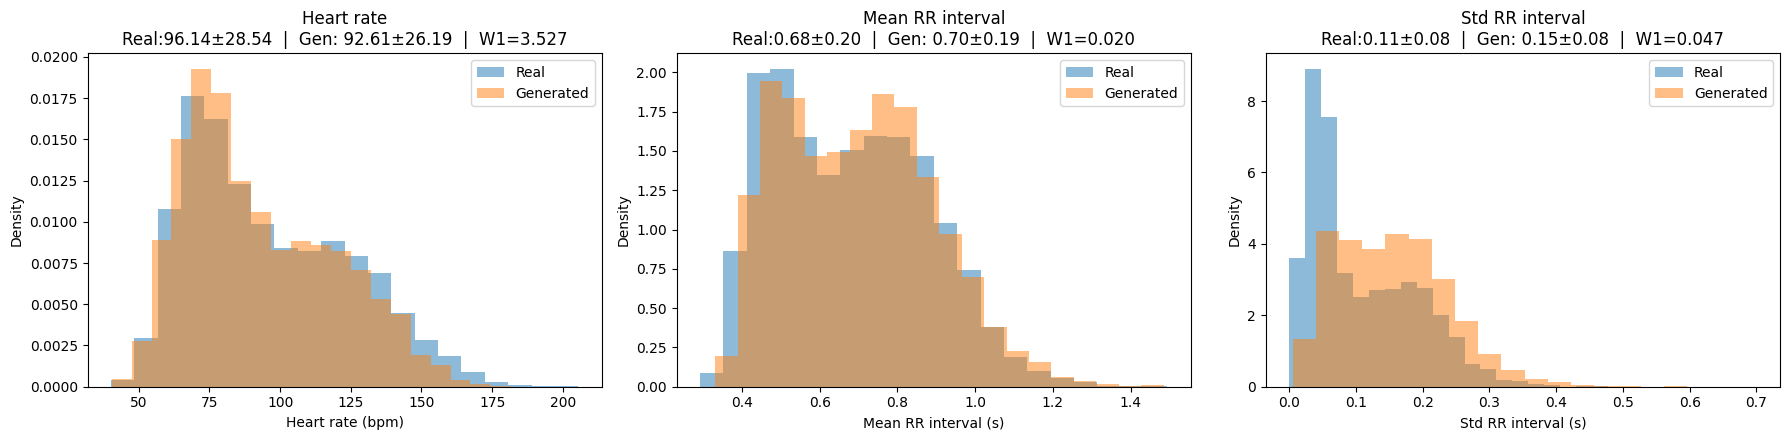

In [ ]:
real_metrics_df = compute_dataset_metrics(data_train, fs=SAMPLING_RATE)
gen_metrics_df = compute_dataset_metrics(synthetic_functions, fs=SAMPLING_RATE)
report = full_report(real_metrics_df, gen_metrics_df)

Saved -> ../../results/data/generated_diffusion_samples.pt  (1867.69 MB)


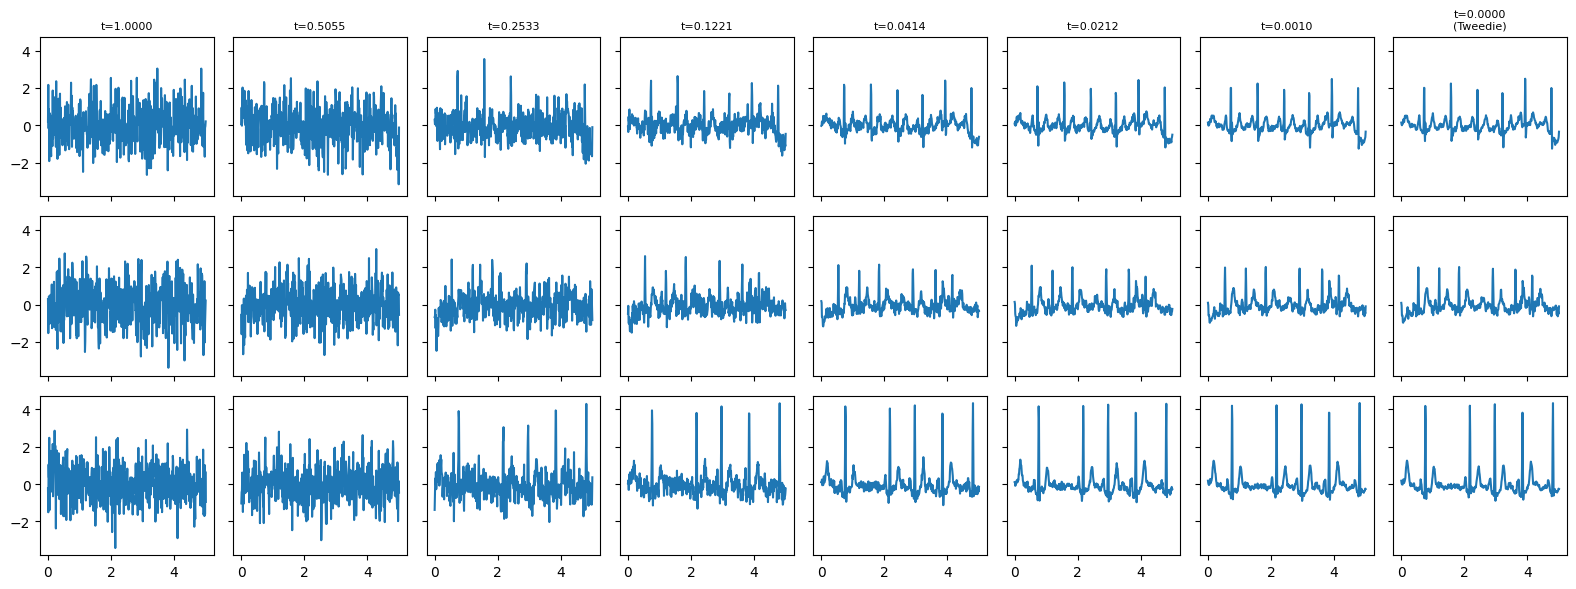

In [ ]:
synthetic_functions_t = torch.cat(
    [synthetic_functions_t, synthetic_functions_norm.unsqueeze(1)],
    dim=1,
    )

save_tensor_bundle(
    "generated_diffusion_samples.pt",
    data=synthetic_functions_t,
    seed=seed,
)

plot_ou_diffusion_process(
    synthetic_functions_t,
    axis_x,
    num_steps=8,
    t_start=T,
    t_end=t_eps,
    tweedie_final=True,
)

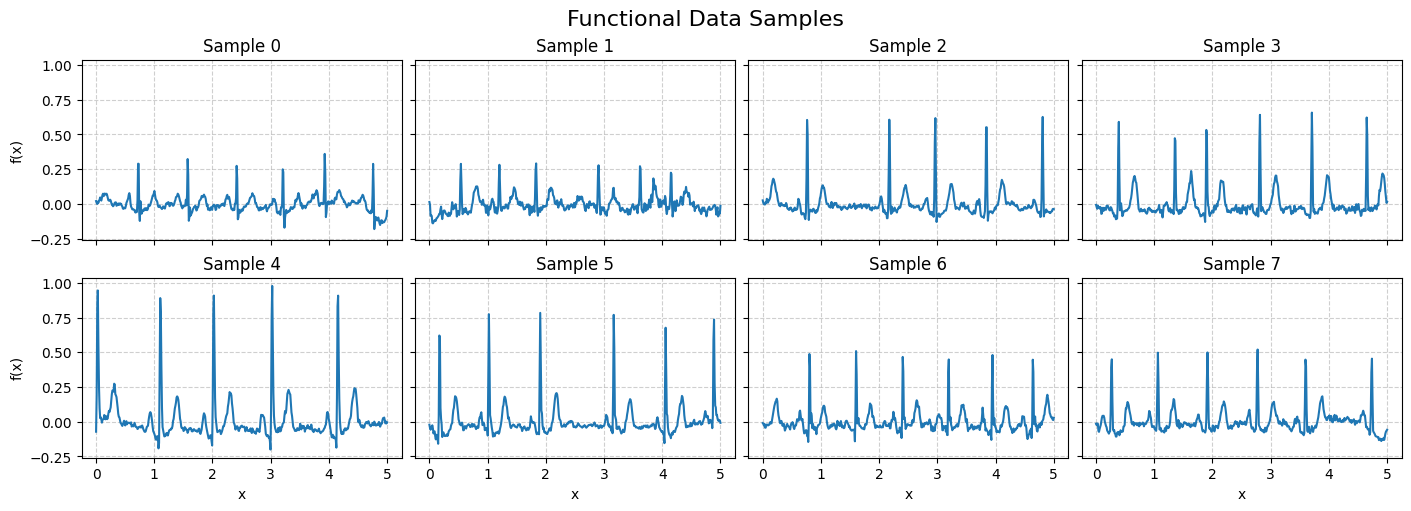

In [ ]:
plot_function_grid(
    synthetic_functions,
    n_plots=8,
    axis_x=axis_x,
)